In [7]:
# General imports
import numpy as np
import matplotlib.pyplot as plt

# cloelite imports
from cloelite.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelite.cosmology.jax_cosmology import JAXBackground

# Validation benchmark is astropy
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import camb

In [8]:
# Cosmology parameters
H0 =  67.7
h = H0/100.
sigma8 = 0.8277
omch2 = 0.12
ombh2 = 0.022
w = -1.
wa = 0.
ns = 0.96
As=2e-9

# Astropy
Tcmb = 2.7255
Neff = 0.0#3.046
YHe = 0.2454

# z-array
z = np.linspace(0, 3, 100)

#astropy_instance = FlatLambdaCDM(H0=H0,Om0=Omm,Ob0=Omb,Tcmb0=Tcmb,Neff=Neff,m_nu=[0,0,0.0]*u.eV)
#H_z_astropy = astropy_instance.H(z).to(u.km/u.s/u.Mpc).value

camb_instance = CAMBBackground(H0=H0, ombh2=ombh2, omch2=omch2, ns=ns, As=As, w=-1.0, wa=0.0, Omk=0.0, sigma8=0.0, gamma_MG=0.0)
H_z_camb = camb_instance.hubble_parameter(z, units='km/s/Mpc')
chi_z_camb = camb_instance.comoving_distance(z)

#jax_instance = JAXBackground(H0=H0,Omc=Omc,Omb=Omb, w=w, wa=wa, sigma8=sigma8, Omk = 0.0, ns = 0.96, As = 2e-9, gamma_MG = 0.545)
#H_z_jax = jax_instance.hubble_parameter(z)

#plt.figure(figsize = (18,8))
#plt.plot(z, 100*(H_z_camb- H_z_astropy)/H_z_astropy, label = 'Astropy vs. CAMB')
#plt.plot(z, 100*(H_z_jax- H_z_astropy)/H_z_astropy, label = 'Astropy vs. JAX')
#plt.ylabel('H(z) Difference [%]')
#plt.title('Percentage Difference in H(z) between Astropy and CAMB')
#plt.xlabel('Redshift z')
#plt.legend()

#Differences are due to neutrinos

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


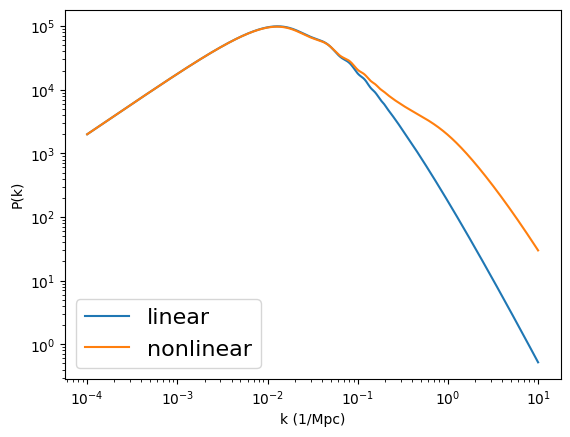

In [9]:
# CAMB PERTURBATIONS
# k-array
k = np.logspace(-4, 1, 1000)
camb_linear = CAMBLinearPerturbations(background=camb_instance, redshifts=z)
camb_nonlinear = CAMBNonLinearPerturbations(linearperturbations=camb_linear, redshifts=z, nonlinear_model='mead2016')
plt.loglog(k, camb_linear.linear_matter_power_spectrum(z, k, kmax=50, extrap_kmax=10)[0, :], label= 'linear')
plt.loglog(k, camb_nonlinear.nonlinear_matter_power_spectrum(z, k, kmax=50, extrap_kmax=10)[0, :], label= 'nonlinear')
plt.xlabel('k (1/Mpc)')
plt.ylabel('P(k)')
plt.legend(fontsize = 16);

In [10]:
camb_instance.As

2e-09

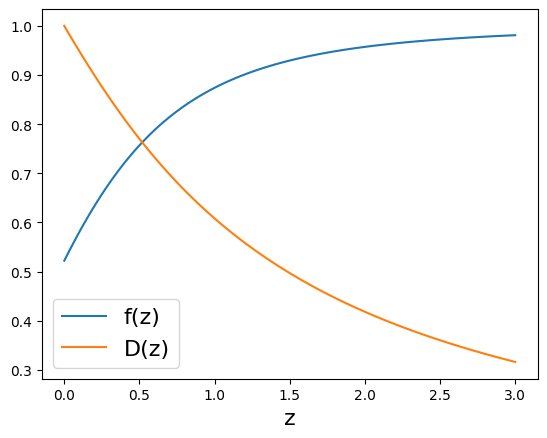

In [11]:
#calculate results for these parameters
plt.plot(z, camb_nonlinear.growth_rate(), label = 'f(z)')
plt.plot(z, camb_nonlinear.growth_factor(z, 0, kmax=50, extrap_kmax=3), label = 'D(z)')
plt.xlabel('z', fontsize = 16)
plt.legend(fontsize = 16);

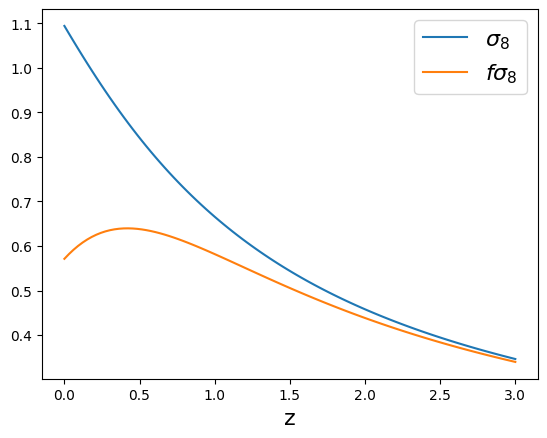

In [12]:
#calculate results for these parameters
plt.plot(z, camb_nonlinear.sigma8(), label = r'$\sigma_8$')
plt.plot(z, camb_nonlinear.fsigma8(), label = r'$f\sigma_8$')
plt.xlabel('z', fontsize = 16)
plt.legend(fontsize = 16);